# Soft Robotic Arm — MuJoCo Simulation

This notebook simulates a **fabric pneumatic soft robotic arm** — a continuum manipulator made from flexible fabric pouches that bend and extend under air pressure.

The physical arm consists of **4 pneumatic columns** (East, North, West, South) arranged around a central axis, each subdivided into **5 independently pressurised floor levels**. Inflating one column more than the others creates a differential elongation that bends the arm toward that column.

```
        plywood mount plate   ← bolted to ceiling/frame
               │
          4 aluminium spacer posts  (118 mm)
               │
           level 0  ──  4 fabric pouches  (red / blue / orange / green)
               │
           level 1
               │
           level 2
               │
           level 3
               │
           level 4  ──  tip disc + OptiTrack marker cross
```

The MuJoCo model has **15 degrees of freedom** — 3 per level (one axial slide + two bending hinges). Pneumatic pressure commands are converted into generalised forces at each physics substep.

In [ ]:
# Install dependencies — run this cell first
%pip install mujoco numpy matplotlib 'imageio[ffmpeg]'

# Colab / headless rendering fix: must be set before mujoco is imported
import os
os.environ['MUJOCO_GL'] = 'egl'   # change to 'osmesa' if EGL is unavailable


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.8/232.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.5/248.5 kB 21.4 MB/s eta 0:00:00


---
## Part 1 — Arm Parameters

The arm's physical dimensions were measured directly from the hardware. Key values:

- **Arm length**: 22 cm at rest (inflating all columns symmetrically extends it further)
- **Spacer posts**: 118 mm long — these hold the arm base away from the plywood mount plate
- **Column offset**: 28 mm from the arm centre — this is also the moment arm used in the pressure-to-torque calculation
- **Column radius**: 18 mm — each fabric pouch is modelled as a capsule geometry
- **Pre-inflation**: a background pressure (typically 1.5 psi) applied to all pouches to give the arm baseline stiffness. Without it, the arm is too floppy to control.

In [ ]:
from dataclasses import dataclass
import numpy as np

@dataclass
class ArmConfig:
    # ── structure ─────────────────────────────────────────────────────────────
    n_segments: int   = 4      # pneumatic columns (East / North / West / South)
    n_pouches:  int   = 5      # floor levels per column

    # ── geometry (measured from physical arm) ─────────────────────────────────
    length:        float = 0.22    # total arm length at rest [m]
    spacer_length: float = 0.118   # distance from plywood mount to arm base [m]
    col_offset:    float = 0.028   # column axis distance from arm centre [m]
    col_radius:    float = 0.018   # column outer radius [m]
    tip_mass:      float = 0.08    # tip OptiTrack marker frame [kg]
    tip_arm:       float = 0.07    # marker cross half-length [m]
    hang_down:     bool  = True    # arm hangs downward from mount plate

    # ── pressure → wrench gains (system-identified) ───────────────────────────
    moment_arm:     float = 0.028               # = col_offset [m]
    pressure_gain:  float = 0.6785140257337393  # [N/psi] bending force per column per level
    extension_gain: float = 0.03475060456198478 # [N/psi] axial force per column per level

    # ── passive mechanics (system-identified) ─────────────────────────────────
    mass:            float = 0.36940816091876827 # total moving mass: fabric + fittings [kg]
    base_stiffness:  float = 0.4591346525394212  # [N·m/rad] per bending joint
    base_damping:    float = 0.053410202628305856 # [N·m·s/rad]
    axial_stiffness: float = 555.3561646910879   # [N/m] per level slide
    axial_damping:   float = 26.746670804400296  # [N·s/m]
    stiffness_per_psi: float = 0.414 # stiffness scale factor per psi pre-inflation

    # ── pneumatics ────────────────────────────────────────────────────────────
    p_max:          float = 10.0    # [psi] max pouch pressure
    tau_pneumatic:  float = 0.12    # [s] first-order fill/vent time constant

    # ── simulation ────────────────────────────────────────────────────────────
    timestep: float = 0.001   # [s] physics dt (1 ms)

    # ── derived properties ────────────────────────────────────────────────────
    @property
    def n_channels(self) -> int:
        return self.n_segments * self.n_pouches

    def level_height(self) -> float:
        """Height of each floor level [m]."""
        return self.length / self.n_pouches

    def col_azimuths(self) -> np.ndarray:
        """Azimuth of each column [rad], shape (4,).
        col 0=East(270°), col 1=North(180°), col 2=West(90°), col 3=South(0°).
        """
        return np.deg2rad([270.0, 180.0, 90.0, 0.0])

    @property
    def mount_z(self) -> float:
        """World Z of the plywood mount plate [m]."""
        # 0.40 m clearance so the arm tip never clips the floor
        return self.length + self.spacer_length + 0.40 if self.hang_down else 0.05


# Instantiate with system-identified parameters
cfg = ArmConfig()

print("=== Geometry ===")
print(f"  Arm length       : {cfg.length*100:.0f} cm")
print(f"  Spacer height    : {cfg.spacer_length*100:.1f} cm")
print(f"  Level height     : {cfg.level_height()*100:.2f} cm  ({cfg.n_pouches} levels)")
print(f"  Mount plate Z    : {cfg.mount_z:.3f} m above floor")
print(f"  Pressure channels: {cfg.n_channels}  ({cfg.n_segments} cols × {cfg.n_pouches} levels)")
print()
print("=== Column azimuths ===")
for i, (label, phi) in enumerate(zip(["East","North","West","South"], cfg.col_azimuths())):
    print(f"  col {i} ({label:5s}) : {np.degrees(phi):.0f} deg")


=== Geometry ===
  Arm length       : 22 cm
  Spacer height    : 11.8 cm
  Level height     : 4.40 cm  (5 levels)
  Mount plate Z    : 0.738 m above floor
  Pressure channels: 20  (4 cols × 5 levels)

=== Column azimuths ===
  col 0 (East ) : 270 deg
  col 1 (North) : 180 deg
  col 2 (West ) : 90 deg
  col 3 (South) : 0 deg


---
## Part 2 — Building the MuJoCo Model

MuJoCo models are described in **MJCF XML**. The arm is a chain of 5 nested rigid bodies — one per floor level — each carrying 3 joints:

- `ext{k}` — a **slide joint** along the arm axis: models axial elongation when a level inflates
- `bx{k}` — a **hinge joint** about X: bending in the Y direction
- `by{k}` — a **hinge joint** about Y: bending in the X direction

Each level also gets 4 coloured **capsule geoms** (one per column) and a thin central core. The colours are fixed:
- 🔴 Red = East (col 0)
- 🔵 Blue = North (col 1)
- 🟠 Orange = West (col 2)
- 🟢 Green = South (col 3)

The **plywood mount plate** and 4 spacer posts are static (no joints), attached to the world at the computed mount height. The **tip disc** with OptiTrack marker spheres sits at the bottom of the chain — this is what the motion capture system tracks in the real lab.

In [ ]:
def build_arm_xml(cfg: ArmConfig) -> str:
    """Generate the MJCF XML string for the 4-column × 5-level soft arm."""
    h        = cfg.level_height()
    n_levels = cfg.n_pouches
    link_mass = cfg.mass / n_levels
    zdir     = -1.0 if cfg.hang_down else 1.0

    col_phis   = cfg.col_azimuths()   # (4,) radians
    col_colors = [
        "0.82 0.18 0.08 1",  # col 0 : red
        "0.08 0.28 0.90 1",  # col 1 : blue
        "0.92 0.55 0.08 1",  # col 2 : orange
        "0.10 0.68 0.18 1",  # col 3 : green
    ]
    disc_r = cfg.col_offset + cfg.col_radius + 0.003  # connector ring radius

    body_xml = ""
    indent   = "      "   # 6 spaces — inside the mount body

    for k in range(n_levels):
        # level 0 sits at the bottom of the spacer posts; subsequent levels
        # are each one step further along the arm (nested inside the previous body)
        if k == 0:
            offset = -cfg.spacer_length if cfg.hang_down else 0.0
        else:
            offset = zdir * h

        body_xml += f'{indent}<body name="level{k}" pos="0 0 {offset:.6f}">\n'

        # ── 3 DOFs ────────────────────────────────────────────────────────────
        # Axial slide
        body_xml += (
            f'{indent}  <joint name="ext{k}" type="slide" axis="0 0 {zdir:g}" '
            f'stiffness="{cfg.axial_stiffness}" damping="{cfg.axial_damping}" '
            f'springref="0" range="-0.005 0.030"/>\n'
        )
        # Bending about X
        body_xml += (
            f'{indent}  <joint name="bx{k}" type="hinge" axis="1 0 0" '
            f'damping="{cfg.base_damping}" stiffness="{cfg.base_stiffness}" springref="0"/>\n'
        )
        # Bending about Y
        body_xml += (
            f'{indent}  <joint name="by{k}" type="hinge" axis="0 1 0" '
            f'damping="{cfg.base_damping}" stiffness="{cfg.base_stiffness}" springref="0"/>\n'
        )

        # ── Connector ring (between levels) ───────────────────────────────────
        body_xml += (
            f'{indent}  <geom name="ring{k}" type="cylinder" pos="0 0 0" '
            f'size="{disc_r:.4f} 0.0025" mass="0.006" '
            f'rgba="0.10 0.10 0.12 1" contype="0" conaffinity="0"/>\n'
        )

        # ── 4 pneumatic column capsules ───────────────────────────────────────
        col_mass = link_mass * 0.85 / cfg.n_segments
        for s, phi in enumerate(col_phis):
            cx = cfg.col_offset * np.cos(phi)
            cy = cfg.col_offset * np.sin(phi)
            body_xml += (
                f'{indent}  <geom name="col{s}_l{k}" type="capsule" '
                f'fromto="{cx:.5f} {cy:.5f} 0 {cx:.5f} {cy:.5f} {zdir*h:.5f}" '
                f'size="{cfg.col_radius:.4f}" mass="{col_mass:.6f}" '
                f'rgba="{col_colors[s]}" contype="0" conaffinity="0"/>\n'
            )

        # ── Central structural core ───────────────────────────────────────────
        body_xml += (
            f'{indent}  <geom name="core{k}" type="cylinder" '
            f'pos="0 0 {zdir*h*0.5:.5f}" '
            f'size="0.005 {h*0.48:.5f}" mass="{link_mass*0.15:.6f}" '
            f'rgba="0.12 0.12 0.14 1" contype="0" conaffinity="0"/>\n'
        )

        indent += "  "   # deeper nesting for next level

    # ── Tip disc + OptiTrack marker frame ─────────────────────────────────────
    a = cfg.tip_arm
    body_xml += (
        f'{indent}<body name="tip_disc" pos="0 0 {zdir*h:.6f}">\n'
        f'{indent}  <geom name="tip_ring" type="cylinder" pos="0 0 0" '
        f'size="{disc_r:.4f} 0.0025" mass="0.010" '
        f'rgba="0.10 0.10 0.12 1" contype="0" conaffinity="0"/>\n'
        f'{indent}  <body name="tip_frame" pos="0 0 {zdir*0.012:.6f}">\n'
        f'{indent}    <geom name="tip_bar_x" type="capsule" '
        f'fromto="-{a} 0 0 {a} 0 0" size="0.004" '
        f'mass="{cfg.tip_mass*0.30:.4f}" rgba="0.12 0.12 0.14 1" '
        f'contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_bar_y" type="capsule" '
        f'fromto="0 -{a} 0 0 {a} 0" size="0.004" '
        f'mass="{cfg.tip_mass*0.30:.4f}" rgba="0.12 0.12 0.14 1" '
        f'contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_ball_c" type="sphere" pos="0 0 0" '
        f'size="0.007" mass="{cfg.tip_mass*0.40:.4f}" '
        f'rgba="0.85 0.85 0.85 1" contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_ball_px" type="sphere" pos="{a} 0 0" '
        f'size="0.005" mass="0.001" rgba="0.85 0.85 0.85 1" contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_ball_nx" type="sphere" pos="-{a} 0 0" '
        f'size="0.005" mass="0.001" rgba="0.85 0.85 0.85 1" contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_ball_py" type="sphere" pos="0 {a} 0" '
        f'size="0.005" mass="0.001" rgba="0.85 0.85 0.85 1" contype="0" conaffinity="0"/>\n'
        f'{indent}    <geom name="tip_ball_ny" type="sphere" pos="0 -{a} 0" '
        f'size="0.005" mass="0.001" rgba="0.85 0.85 0.85 1" contype="0" conaffinity="0"/>\n'
        f'{indent}    <site name="tip" pos="0 0 0" size="0.007" rgba="0.1 0.9 0.3 1"/>\n'
        f'{indent}  </body>\n'
        f'{indent}</body>\n'
    )

    # Close all level bodies (deepest first)
    for k in range(n_levels, 0, -1):
        ind = "      " + "  " * (k - 1)
        body_xml += f"{ind}</body>\n"

    return f"""<mujoco model="fabric_soft_arm">
  <option timestep="{cfg.timestep}" gravity="0 0 -9.81" integrator="implicitfast"/>
  <visual>
    <headlight ambient="0.45 0.45 0.48" diffuse="0.7 0.7 0.7" specular="0.1 0.1 0.1"/>
    <global offwidth="1280" offheight="720"/>
    <quality shadowsize="2048"/>
  </visual>
  <asset>
    <texture name="grid" type="2d" builtin="checker" width="512" height="512"
             rgb1="0.18 0.20 0.24" rgb2="0.24 0.26 0.30"/>
    <material name="grid" texture="grid" texrepeat="8 8" reflectance="0.08"/>
    <material name="mount_wood" rgba="0.62 0.48 0.30 1"/>
    <material name="post_metal" rgba="0.14 0.14 0.16 1"/>
  </asset>
  <worldbody>
    <light pos="0.0 -0.8 1.8" dir="0.0 0.5 -1" diffuse="0.6 0.6 0.65" specular="0.2 0.2 0.2"/>
    <light pos="0.6 0.4 1.5" dir="-0.4 -0.3 -1" diffuse="0.4 0.4 0.45" specular="0.1 0.1 0.1"/>
    <geom name="floor" type="plane" size="2.0 2.0 0.05" material="grid"/>
    <body name="mount" pos="0 0 {cfg.mount_z:.4f}">
      <!-- Plywood mount plate (~15x15 cm) -->
      <geom name="mount_plate" type="box" size="0.150 0.150 0.009"
            material="mount_wood" contype="0" conaffinity="0"/>
      <!-- 4 spacer posts -->
      <geom name="spacer_fl" type="box" fromto="-0.035 -0.035 0 -0.035 -0.035 -{cfg.spacer_length:.4f}"
            size="0.006 0.006 0.006" material="post_metal" contype="0" conaffinity="0"/>
      <geom name="spacer_fr" type="box" fromto=" 0.035 -0.035 0  0.035 -0.035 -{cfg.spacer_length:.4f}"
            size="0.006 0.006 0.006" material="post_metal" contype="0" conaffinity="0"/>
      <geom name="spacer_bl" type="box" fromto="-0.035  0.035 0 -0.035  0.035 -{cfg.spacer_length:.4f}"
            size="0.006 0.006 0.006" material="post_metal" contype="0" conaffinity="0"/>
      <geom name="spacer_br" type="box" fromto=" 0.035  0.035 0  0.035  0.035 -{cfg.spacer_length:.4f}"
            size="0.006 0.006 0.006" material="post_metal" contype="0" conaffinity="0"/>
      <!-- Base disc (bottom of spacer posts, top of arm) -->
      <geom name="mount_disc" type="box" pos="0 0 -{cfg.spacer_length:.4f}"
            size="0.045 0.045 0.003" mass="0.010"
            rgba="0.10 0.10 0.12 1" contype="0" conaffinity="0"/>
{body_xml}    </body>
  </worldbody>
  <sensor>
    <framepos    name="tip_pos"  objtype="site" objname="tip"/>
    <framequat   name="tip_quat" objtype="site" objname="tip"/>
    <framelinvel name="tip_vel"  objtype="site" objname="tip"/>
  </sensor>
</mujoco>
"""


# Generate and load the model
import mujoco

xml   = build_arm_xml(cfg)
model = mujoco.MjModel.from_xml_string(xml)
data  = mujoco.MjData(model)
mujoco.mj_forward(model, data)

print(f"Model loaded successfully!")
print(f"  DOFs   (nq)   : {model.nq}  — 5 levels x 3 (ext + bx + by)")
print(f"  Bodies (nbody): {model.nbody}")
print(f"  Geoms  (ngeom): {model.ngeom}")
print(f"  Sensors       : {model.nsensor}")

print("\nBodies and their world positions at rest:")
for i in range(model.nbody):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_BODY, i)
    print(f"  [{i}] {name:15s}  Z = {data.xpos[i, 2]:.4f} m")

Model loaded successfully!
  DOFs   (nq)   : 15  — 5 levels x 3 (ext + bx + by)
  Bodies (nbody): 9
  Geoms  (ngeom): 45
  Sensors       : 3

Bodies and their world positions at rest:
  [0] world            Z = 0.0000 m
  [1] mount            Z = 0.7380 m
  [2] level0           Z = 0.6200 m
  [3] level1           Z = 0.5760 m
  [4] level2           Z = 0.5320 m
  [5] level3           Z = 0.4880 m
  [6] level4           Z = 0.4440 m
  [7] tip_disc         Z = 0.4000 m
  [8] tip_frame        Z = 0.3880 m


---
## Part 3 — Simulating Pneumatic Actuation

Real pneumatic pouches don't respond instantaneously — there's a fill/vent delay as air flows through the tubing. This is modelled with a **first-order lag filter** per pouch:

```
p_actual += α × (p_commanded − p_actual)    where α = dt / τ,  τ = 120 ms
```

Each physics substep (1 ms), the actual pressure creeps toward the commanded value. At 100 Hz control, pressure settles to ~95% of the target in about 360 ms.

**Pressure → force mapping:** At each floor level `k`, the 4 column pressures produce:
1. A **bending moment** on `bx{k}` and `by{k}` — the net torque points toward whichever column is inflated most
2. An **axial extension force** on `ext{k}` — proportional to the *sum* of all 4 column pressures at that level

The gains (`pressure_gain = 0.552 N/psi`, `moment_arm = 28 mm`) were tuned to match observed tip deflection on the physical arm.

**Sensor model:** The simulated pouch pressure sensors read actual pressure plus a curvature-coupling term (bending a level compresses its pouches slightly) and an extension term — matching the parallel-topology sensor behaviour measured on the real hardware.

In [ ]:
class SoftArmSim:
    """MuJoCo digital twin of the fabric pneumatic soft arm.

    P[s, k] = pressure [psi] in column s at floor level k.
      s: 0=East, 1=North, 2=West, 3=South
      k: 0=top level, 4=bottom level
    """

    def __init__(self, cfg: ArmConfig | None = None, control_hz: float = 100.0,
                 sensor_noise_psi: float = 0.007, curvature_coupling: float = 4.0,
                 extension_coupling: float = 30.0, seed: int | None = 0):
        self.cfg           = cfg or ArmConfig()
        self.control_dt    = 1.0 / control_hz
        self.n_sub_steps   = max(1, round(self.control_dt / self.cfg.timestep))
        self.sensor_noise  = sensor_noise_psi
        self.curv_coupling = curvature_coupling
        self.ext_coupling  = extension_coupling
        self.rng           = np.random.default_rng(seed)

        self.model = mujoco.MjModel.from_xml_string(build_arm_xml(self.cfg))
        self.data  = mujoco.MjData(self.model)

        cfg = self.cfg

        # ── DOF address lookup ────────────────────────────────────────────────
        def dof(name: str) -> int:
            j = mujoco.mj_name2id(self.model, mujoco.mjtObj.mjOBJ_JOINT, name)
            return self.model.jnt_dofadr[j]

        self.ext_dofs  = np.array([dof(f"ext{k}") for k in range(cfg.n_pouches)])
        self.bend_dofs = np.array(
            [(dof(f"bx{k}"), dof(f"by{k}")) for k in range(cfg.n_pouches)]
        )   # shape (5, 2)

        self._base_stiffness = self.model.jnt_stiffness.copy()
        self._base_damping   = self.model.dof_damping.copy()

        # ── Bending axes: column s bends arm in direction col_axes[s] ─────────
        phis = cfg.col_azimuths()   # (4,)
        self.col_axes = np.stack([-np.sin(phis), np.cos(phis)], axis=1)  # (4, 2)
        if cfg.hang_down:
            self.col_axes = -self.col_axes

        self.p_actual = np.zeros((cfg.n_segments, cfg.n_pouches))
        self.p_pre    = 0.0
        self._renderer = None
        mujoco.mj_forward(self.model, self.data)

    # ── Public API ────────────────────────────────────────────────────────────
    def reset(self) -> dict:
        """Reset to zero-pressure resting state."""
        mujoco.mj_resetData(self.model, self.data)
        self.p_actual[:] = 0.0
        mujoco.mj_forward(self.model, self.data)
        return self.observe()

    def set_pre_inflation(self, p_pre_psi: float) -> None:
        """Apply a uniform background pressure to stiffen the arm."""
        self.p_pre = float(np.clip(p_pre_psi, 0.0, self.cfg.p_max))
        scale = 1.0 + self.cfg.stiffness_per_psi * self.p_pre
        self.model.jnt_stiffness[:] = self._base_stiffness * scale
        self.model.dof_damping[:]   = self._base_damping   * np.sqrt(scale)

    def step(self, p_cmd_psi) -> dict:
        """Advance one 10 ms control tick.

        p_cmd_psi can be:
          (4, 5)  — full per-pouch command
          (4,)    — one value per column, broadcast to all levels
          (5,)    — one value per level, broadcast to all columns
          (20,)   — flat, reshaped to (4, 5)
        """
        cfg   = self.cfg
        p_cmd = np.asarray(p_cmd_psi, dtype=float)

        if p_cmd.ndim == 1:
            if p_cmd.size == cfg.n_channels:
                p_cmd = p_cmd.reshape(cfg.n_segments, cfg.n_pouches)
            elif p_cmd.size == cfg.n_segments:
                p_cmd = np.tile(p_cmd[:, None], (1, cfg.n_pouches))
            elif p_cmd.size == cfg.n_pouches:
                p_cmd = np.tile(p_cmd[None, :], (cfg.n_segments, 1))

        p_cmd = p_cmd.reshape(cfg.n_segments, cfg.n_pouches)
        p_cmd = np.clip(p_cmd + self.p_pre, 0.0, cfg.p_max)

        # First-order pneumatic lag filter
        alpha = cfg.timestep / max(cfg.tau_pneumatic, cfg.timestep)
        for _ in range(self.n_sub_steps):
            self.p_actual += alpha * (p_cmd - self.p_actual)
            self._apply_pressure_wrench()
            mujoco.mj_step(self.model, self.data)

        return self.observe()

    def observe(self) -> dict:
        """Return the current observation."""
        s = self.data.sensordata
        return {
            "time":             self.data.time,
            "tip_pos":          s[0:3].copy(),    # [m] world position of tip
            "tip_quat":         s[3:7].copy(),    # tip orientation quaternion
            "tip_vel":          s[7:10].copy(),   # [m/s] tip velocity
            "pouch_pressures":  self._pouch_sensors(),  # (4, 5) [psi]
            "p_actual":         self.p_actual.copy(),
            "q":                self.data.qpos.copy(),  # (15,) joint positions
        }

    def render_frame(self, cam_azimuth: float = 135, cam_elevation: float = -20,
                     cam_distance: float = 0.80, width: int = 640, height: int = 480):
        """Render and return an (H, W, 3) uint8 RGB frame."""
        if self._renderer is None:
            self._renderer = mujoco.Renderer(self.model, height, width)
        cfg = self.cfg
        cam = mujoco.MjvCamera()
        cam.azimuth, cam.elevation, cam.distance = cam_azimuth, cam_elevation, cam_distance
        # Centre between plywood plate (top) and arm tip (bottom)
        arm_tip_z = cfg.mount_z - cfg.length - cfg.spacer_length
        cam.lookat[:] = [0.0, 0.0, (cfg.mount_z + arm_tip_z) * 0.5]
        self._renderer.update_scene(self.data, camera=cam)
        return self._renderer.render()

    # ── Internal ──────────────────────────────────────────────────────────────
    def _apply_pressure_wrench(self) -> None:
        """Convert (4x5) pouch pressures into generalised forces on the joints."""
        cfg = self.cfg
        qf  = self.data.qfrc_applied
        qf[:] = 0.0
        gain = cfg.pressure_gain * cfg.moment_arm

        # Bending moment at each level: m[k] = gain * sum_s(p[s,k] * axis[s])
        m = gain * (self.p_actual.T @ self.col_axes)   # (5, 2)

        for k in range(cfg.n_pouches):
            bx, by = self.bend_dofs[k]
            qf[bx] += m[k, 0]
            qf[by] += m[k, 1]
            # Symmetric inflation → axial extension
            qf[self.ext_dofs[k]] += cfg.extension_gain * self.p_actual[:, k].sum()

    def _level_curvatures(self) -> np.ndarray:
        """Per-level bending angles, shape (5, 2)."""
        q   = self.data.qpos
        out = np.zeros((self.cfg.n_pouches, 2))
        for k in range(self.cfg.n_pouches):
            bx, by = self.bend_dofs[k]
            out[k] = q[bx], q[by]
        return out

    def _pouch_sensors(self) -> np.ndarray:
        """Simulated pouch pressure sensors, shape (4, 5).
        Reads = actual pressure + curvature coupling + extension coupling + noise.
        """
        bend  = self._level_curvatures()              # (5, 2)
        kappa = (bend @ self.col_axes.T).T            # (4, 5)
        ext   = self.data.qpos[self.ext_dofs][None, :]
        p_meas = (self.p_actual
                  + self.curv_coupling * kappa
                  + self.ext_coupling  * ext)
        if self.sensor_noise > 0:
            p_meas += self.rng.normal(0, self.sensor_noise, p_meas.shape)
        return p_meas


# Quick sanity check
sim = SoftArmSim()
obs = sim.reset()
print("Observation keys :", list(obs.keys()))
print("tip_pos at rest  :", np.round(obs['tip_pos'], 4), "m")
print("qpos shape       :", obs['q'].shape, " (15 DOFs)")
print("pressures shape  :", obs['pouch_pressures'].shape, " (4 cols x 5 levels)")

Observation keys : ['time', 'tip_pos', 'tip_quat', 'tip_vel', 'pouch_pressures', 'p_actual', 'q']
tip_pos at rest  : [0.    0.    0.388] m
qpos shape       : (15,)  (15 DOFs)
pressures shape  : (4, 5)  (4 cols x 5 levels)


---
## Part 4 — Arm at Rest

With zero pressure commands, the arm hangs vertically under gravity. The passive stiffness and damping of the joints (tuned to match the fabric's measured compliance) keep it stable. The plywood mount plate is visible at the top, the four coloured columns run the full length of the arm, and the OptiTrack marker cross sits at the tip.

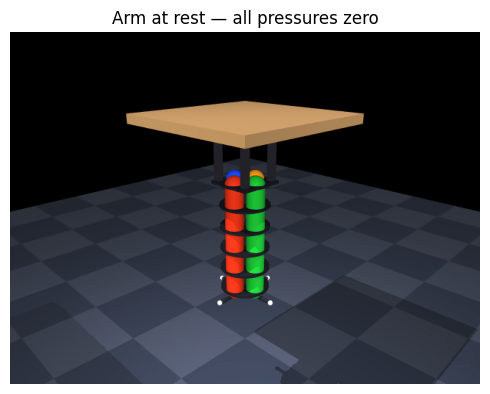

In [ ]:
import matplotlib.pyplot as plt

sim.reset()
frame_rest = sim.render_frame(cam_azimuth=135, cam_elevation=-20, cam_distance=0.82)

plt.figure(figsize=(5, 5))
plt.imshow(frame_rest)
plt.axis("off")
plt.title("Arm at rest — all pressures zero", fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 5 — Single Column Actuation

Pressurising the **East column (col 0)** at 4 psi across all 5 levels causes the arm to bend toward the East. The bending is driven by the moment the elongating column creates around the arm's central axis.

Note the **pneumatic lag** in the sensor readings — the pressure rises gradually over ~300 ms rather than jumping instantly. The sensor for col 0 reads higher than commanded because curvature-coupling (bending compresses the East pouches) adds to the measured pressure.

In [ ]:
sim = SoftArmSim()
sim.set_pre_inflation(1.5)   # 1.5 psi background stiffness
sim.reset()

P = np.zeros((4, 5))   # shape: (n_columns, n_levels)
P[0, :] = 4.0          # East column, all 5 levels at 4 psi

n_steps = 300           # 3 seconds at 100 Hz
t_log   = np.zeros(n_steps)
tip_log = np.zeros((n_steps, 3))
P_log   = np.zeros((n_steps, 4, 5))

for i in range(n_steps):
    obs      = sim.step(P)
    t_log[i] = obs["time"]
    tip_log[i] = obs["tip_pos"]
    P_log[i]   = obs["pouch_pressures"]

disp = (tip_log[-1] - tip_log[0]) * 100   # cm
print(f"Tip displacement after 3 s:")
print(f"  ΔX = {disp[0]:+.1f} cm")
print(f"  ΔY = {disp[1]:+.1f} cm")
print(f"  ΔZ = {disp[2]:+.1f} cm  (axial extension)")

Tip displacement after 3 s:
  ΔX = -0.0 cm
  ΔY = -2.8 cm
  ΔZ = -1.5 cm  (axial extension)


/tmp/ipykernel_3299/2151368713.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


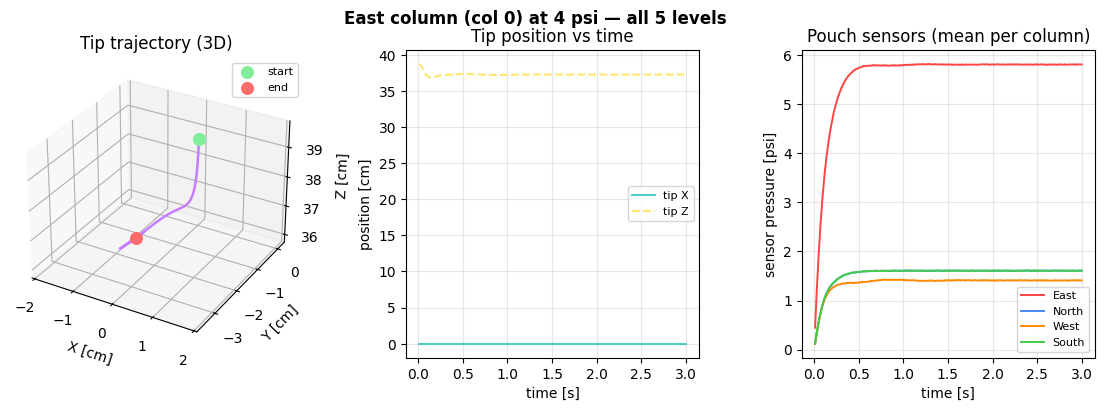

In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (enables projection="3d")
import matplotlib.gridspec as gridspec

col_labels = ["East", "North", "West", "South"]
col_colors = ["#FF4444", "#4488FF", "#FF8800", "#44CC44"]

fig = plt.figure(figsize=(14, 4))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# 3D tip trajectory
ax = fig.add_subplot(gs[0], projection="3d")
x_cm, y_cm, z_cm = tip_log[:, 0]*100, tip_log[:, 1]*100, tip_log[:, 2]*100
ax.plot(x_cm, y_cm, z_cm, color="#C77DFF", lw=1.8)
ax.scatter(x_cm[0],  y_cm[0],  z_cm[0],  color="#80ED99", s=70, zorder=5, label="start")
ax.scatter(x_cm[-1], y_cm[-1], z_cm[-1], color="#FF6B6B", s=70, zorder=5, label="end")
ax.set_xlabel("X [cm]"); ax.set_ylabel("Y [cm]"); ax.set_zlabel("Z [cm]")
ax.set_title("Tip trajectory (3D)")

# Floor a shared half-range on every axis (centred on the data, padded 20%)
# so a near-1D bend doesn't collapse into unreadable slivers on any axis.
cx = (x_cm.max() + x_cm.min()) / 2
cy = (y_cm.max() + y_cm.min()) / 2
cz = (z_cm.max() + z_cm.min()) / 2
half = max(x_cm.max()-x_cm.min(), y_cm.max()-y_cm.min(), z_cm.max()-z_cm.min(), 0.5) / 2 * 1.2
ax.set_xlim(cx - half, cx + half)
ax.set_ylim(cy - half, cy + half)
ax.set_zlim(cz - half, cz + half)
ax.legend(fontsize=8)

# Tip position vs time
ax = fig.add_subplot(gs[1])
ax.plot(t_log, tip_log[:, 0]*100, label="tip X", color="#4ECDC4", lw=1.5)
ax.plot(t_log, tip_log[:, 2]*100, label="tip Z", color="#FFE66D", lw=1.5, ls="--")
ax.set_xlabel("time [s]"); ax.set_ylabel("position [cm]")
ax.set_title("Tip position vs time"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Sensor pressures
ax = fig.add_subplot(gs[2])
for s, (label, color) in enumerate(zip(col_labels, col_colors)):
    ax.plot(t_log, P_log[:, s, :].mean(axis=1), color=color, label=label, lw=1.4)
ax.set_xlabel("time [s]"); ax.set_ylabel("sensor pressure [psi]")
ax.set_title("Pouch sensors (mean per column)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("East column (col 0) at 4 psi — all 5 levels", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 6 — Comparing Rest and Actuated States

Side-by-side render showing the arm straight (zero pressure) versus bent under 4 psi East column pressure. The tip displacement is visible — roughly 2 cm lateral deflection, consistent with measurements on the physical arm at this pressure level.

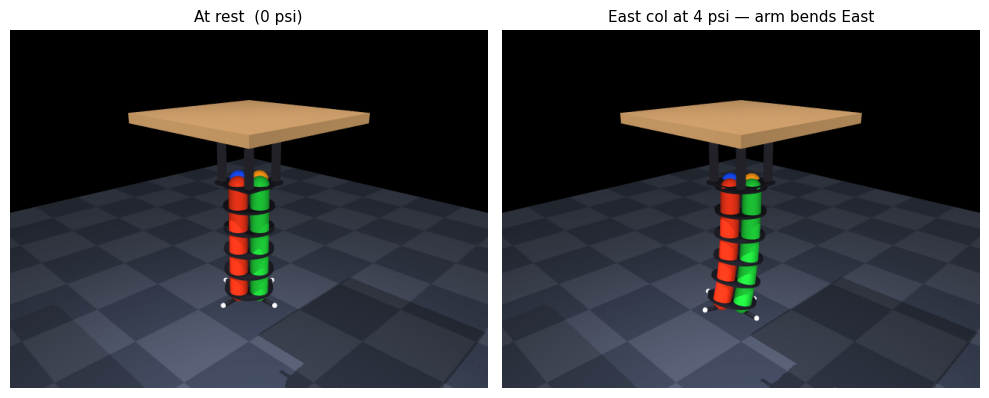

In [ ]:
frame_bent = sim.render_frame(cam_azimuth=135, cam_elevation=-20, cam_distance=0.82)

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 5))
ax_l.imshow(frame_rest); ax_l.axis("off")
ax_l.set_title("At rest  (0 psi)", fontsize=11)
ax_r.imshow(frame_bent); ax_r.axis("off")
ax_r.set_title("East col at 4 psi — arm bends East", fontsize=11)
plt.tight_layout()
plt.show()

---
## Part 7 — Column Bending Directions

Each of the 4 columns actuated independently. This confirms that the column azimuth assignments in the model match the physical arm layout — each column bends the arm in its designated compass direction. These renders serve as a visual sanity check against real hardware behaviour.

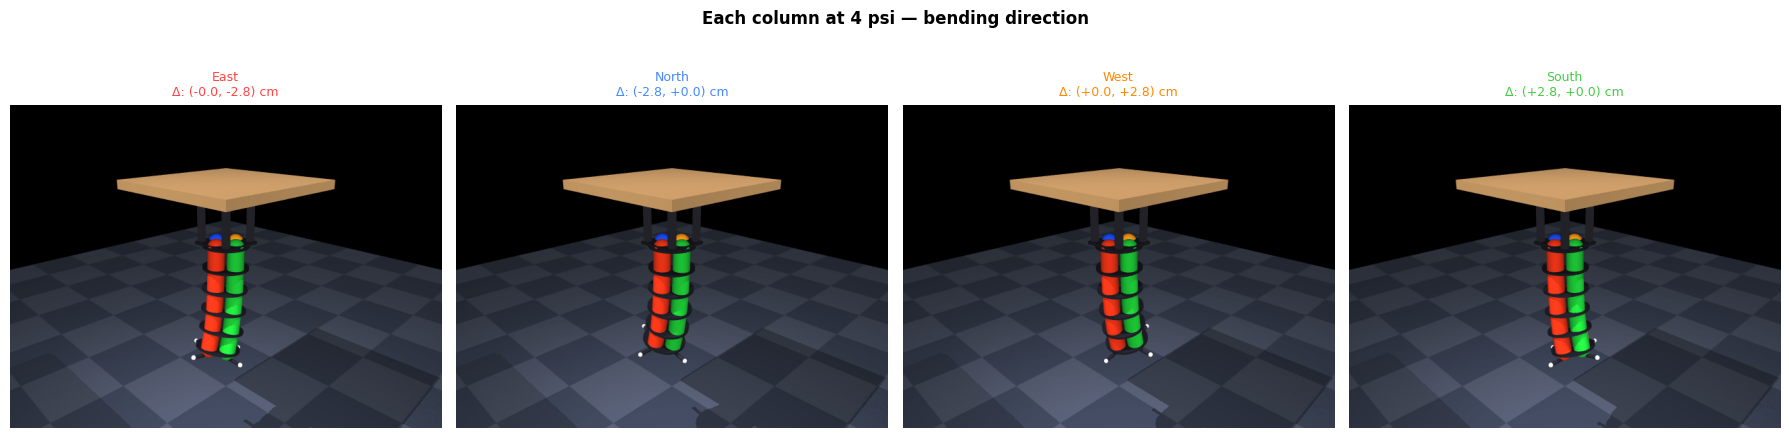

In [ ]:
frames, tips = [], []
for s in range(4):
    sim = SoftArmSim()
    sim.set_pre_inflation(1.5)
    sim.reset()
    P = np.zeros((4, 5))
    P[s, :] = 4.0
    for _ in range(300):
        obs = sim.step(P)
    tips.append(obs["tip_pos"].copy())
    frames.append(sim.render_frame(cam_azimuth=135, cam_elevation=-20, cam_distance=0.82))

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, frame, label, color, tip in zip(axes, frames, col_labels, col_colors, tips):
    ax.imshow(frame)
    ax.set_title(f"{label}\nΔ: ({tip[0]*100:+.1f}, {tip[1]*100:+.1f}) cm",
                 fontsize=9, color=color)
    ax.axis("off")
plt.suptitle("Each column at 4 psi — bending direction", fontweight="bold", fontsize=12)
plt.tight_layout()
plt.show()

---
## Part 8 — Circular Tip Trajectory

By applying **phase-shifted sinusoidal pressures** to the four columns, the net bending direction rotates continuously, sweeping the tip around a circle in the workspace.

```
East  : A × max(0,  sin(2π f t))
North : A × max(0,  sin(2π f t + π/2))
West  : A × max(0,  sin(2π f t + π))
South : A × max(0,  sin(2π f t + 3π/2))
```

Only one or two columns are active at any moment (the `max(0, …)` clips negatives since pressure can't go below zero). The 90° phase spacing between adjacent columns produces a smooth circular motion. This pattern is used in the demo scripts to validate the workspace geometry.

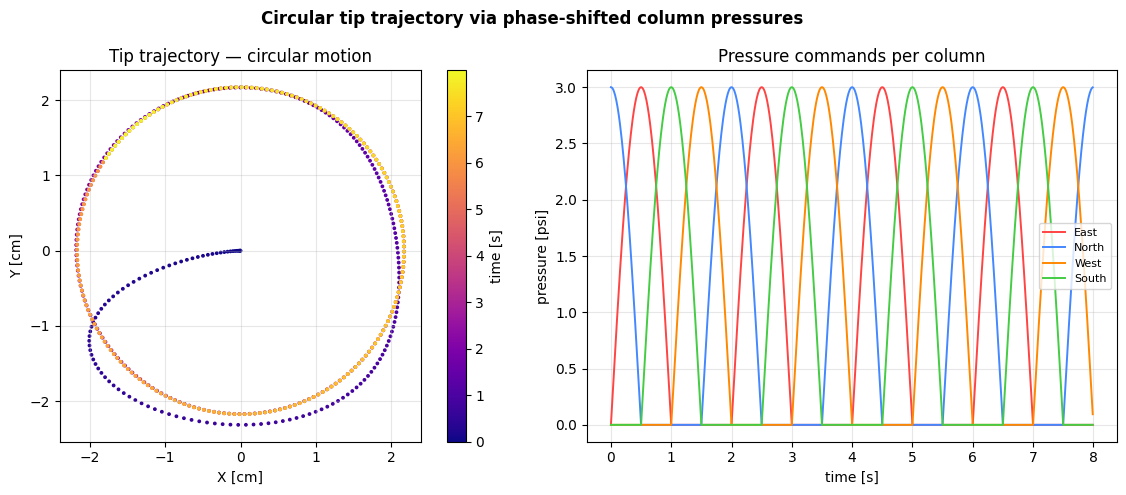

In [ ]:
sim = SoftArmSim()
sim.set_pre_inflation(1.5)
sim.reset()

duration = 8.0
n_steps  = int(duration * 100)
t_arr    = np.arange(n_steps) / 100.0
freq, amp = 0.5, 3.0   # Hz, psi

tip_c  = np.zeros((n_steps, 3))
P_hist = []

for i in range(n_steps):
    t = t_arr[i]
    P = np.zeros((4, 5))
    P[0, :] = amp * max(0,  np.sin(2*np.pi*freq*t))              # East
    P[1, :] = amp * max(0,  np.sin(2*np.pi*freq*t + np.pi/2))   # North
    P[2, :] = amp * max(0,  np.sin(2*np.pi*freq*t + np.pi))     # West
    P[3, :] = amp * max(0,  np.sin(2*np.pi*freq*t + 3*np.pi/2)) # South
    obs = sim.step(P)
    tip_c[i] = obs["tip_pos"]
    P_hist.append(P.copy())

P_arr = np.array(P_hist)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sc = ax.scatter(tip_c[:, 0]*100, tip_c[:, 1]*100, c=t_arr, cmap="plasma", s=3)
plt.colorbar(sc, ax=ax, label="time [s]")
ax.set_xlabel("X [cm]"); ax.set_ylabel("Y [cm]")
ax.set_title("Tip trajectory — circular motion")
ax.set_aspect("equal"); ax.grid(alpha=0.3)

ax = axes[1]
for s, (label, color) in enumerate(zip(col_labels, col_colors)):
    ax.plot(t_arr, P_arr[:, s, 0], color=color, label=label, lw=1.4)
ax.set_xlabel("time [s]"); ax.set_ylabel("pressure [psi]")
ax.set_title("Pressure commands per column")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Circular tip trajectory via phase-shifted column pressures", fontweight="bold")
plt.tight_layout()
plt.show()

---
## Part 9 — Axial Extension

Pressurising all 4 columns **equally** cancels the bending moments — they point in opposite directions and sum to zero. The only net effect is an **axial extension force** on each level's slide joint, making the arm grow longer while staying straight.

This is useful for tasks that require reach adjustment without changing the bending direction, and it lets us measure the extension gain independently from the bending gain.

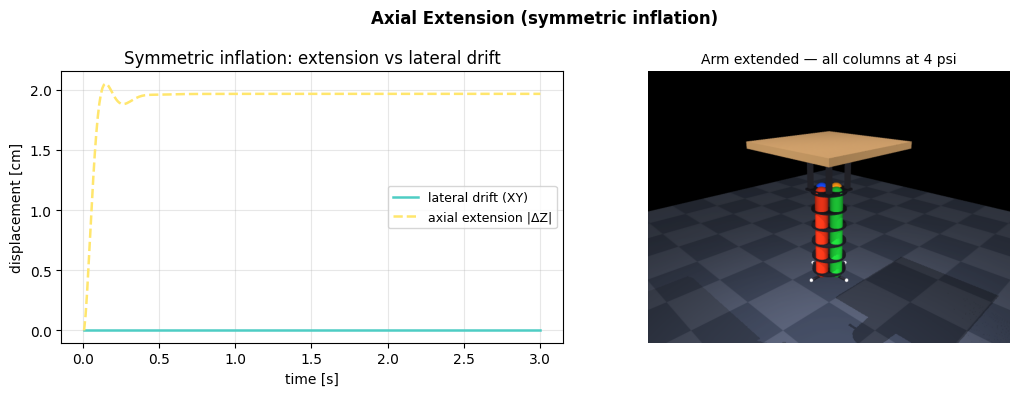

Max lateral drift : 0.00 cm   (should be near zero)
Max axial extension: 2.05 cm


In [ ]:
sim_ax = SoftArmSim()
sim_ax.set_pre_inflation(1.5)
sim_ax.reset()

P_ax = np.ones((4, 5)) * 4.0   # all 4 columns equal → pure axial

n_ax = 300
t_ax, tip_ax = np.zeros(n_ax), np.zeros((n_ax, 3))
for i in range(n_ax):
    obs = sim_ax.step(P_ax)
    t_ax[i]   = obs['time']
    tip_ax[i] = obs['tip_pos']

lateral = np.hypot(tip_ax[:, 0], tip_ax[:, 1]) * 100   # cm
z_ext   = (tip_ax[:, 2] - tip_ax[0, 2]) * 100            # cm (negative = longer)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(t_ax, lateral,  color='#4ECDC4', lw=1.8, label='lateral drift (XY)')
axes[0].plot(t_ax, np.abs(z_ext), color='#FFE66D', lw=1.8, ls='--', label='axial extension |ΔZ|')
axes[0].set_xlabel('time [s]'); axes[0].set_ylabel('displacement [cm]')
axes[0].set_title('Symmetric inflation: extension vs lateral drift')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

frame_ax = sim_ax.render_frame(cam_azimuth=135, cam_elevation=-20, cam_distance=0.90)
axes[1].imshow(frame_ax); axes[1].axis('off')
axes[1].set_title('Arm extended — all columns at 4 psi', fontsize=10)

plt.suptitle('Axial Extension (symmetric inflation)', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Max lateral drift : {lateral.max():.2f} cm   (should be near zero)')
print(f'Max axial extension: {np.abs(z_ext).max():.2f} cm')


---
## Part 10 — Triangle Trajectory

The tip traces a triangle by sweeping between 3 vertices (0°, 120°, 240°), one edge every `T_per_edge = 2.5 s`. This now matches the validated reference implementation (`triangle_demo()` in `demo.py`): at each timestep, the two Cartesian **unit vectors** of the vertices bounding the current edge are linearly interpolated, and that target direction is projected onto each column's axis via `A_drive * (tx·cos(col_phi) + ty·sin(col_phi))`, clipped at zero (pressure can't go negative) — no renormalisation of the weights. Interpolating the direction vector this way traces a straight edge; sweeping the azimuth angle directly at constant amplitude (the earlier approach here, and what the circle demo does on purpose) traces a circular arc instead, which is why the triangle previously came out rounded.

This trajectory tests the arm's ability to hold intermediate bending directions and is useful for verifying linearity of the pressure-to-angle relationship.

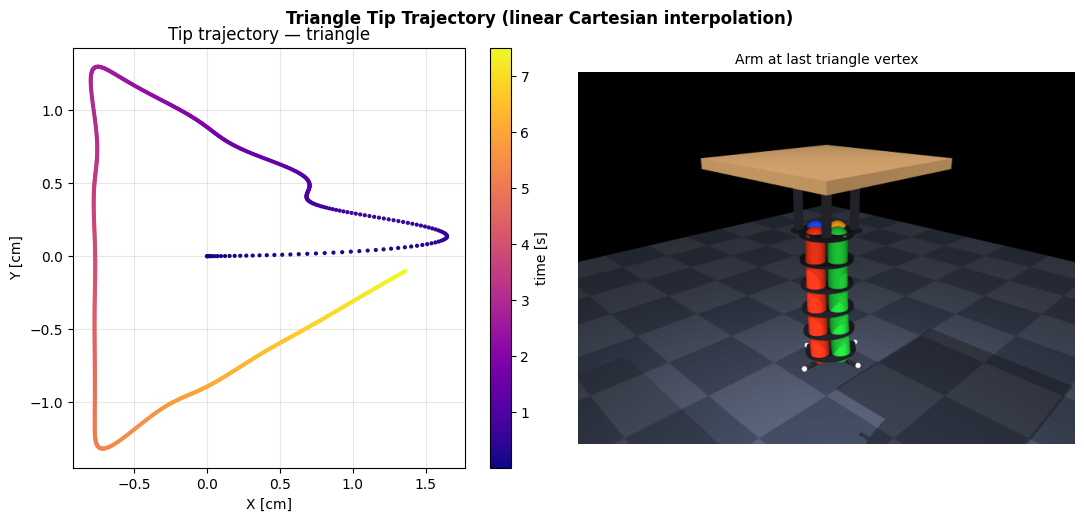

In [ ]:
sim_tri = SoftArmSim()
sim_tri.set_pre_inflation(1.5)
sim_tri.reset()

col_phis = sim_tri.cfg.col_azimuths()   # (4,) column azimuths, straight from cfg

n_vertices    = 3
T_per_edge    = 2.5     # [s] time to sweep each triangle edge
A_drive       = 2.2     # [psi] pressure amplitude
HZ            = 100     # control rate (matches SoftArmSim default control_hz)
vertex_angles = np.deg2rad(np.arange(n_vertices) * 360.0 / n_vertices)   # 0°, 120°, 240°


def triangle_pressure_trajectory(vertex_angles, T_per_edge, A_drive, col_phis, hz=HZ):
    """Direct (vectorised) port of demo.py's triangle_demo() pressure law.

    Linearly interpolates the Cartesian UNIT vectors of the two vertices
    bounding the current edge (a straight line by construction), then
    projects that target direction onto each column's axis — cosine tuning,
    clipped at zero, with NO renormalisation of the weights. This matches
    the reference implementation exactly; interpolating the azimuth angle
    directly instead traces a circular arc between vertices, not a straight
    edge.
    """
    n_vertices = len(vertex_angles)
    n_steps    = int(n_vertices * T_per_edge * hz)
    t          = np.arange(n_steps) / hz

    frac   = (t % T_per_edge) / T_per_edge
    v_cur  = (t / T_per_edge).astype(int) % n_vertices
    v_next = (v_cur + 1) % n_vertices

    xy     = np.stack([np.cos(vertex_angles), np.sin(vertex_angles)], axis=1)   # (n_vertices, 2)
    v0, v1 = xy[v_cur], xy[v_next]                                              # (n_steps, 2)
    target = v0 + frac[:, None] * (v1 - v0)                                    # (n_steps, 2)

    cmd = A_drive * (target[:, 0:1] * np.cos(col_phis)[None, :]
                      + target[:, 1:2] * np.sin(col_phis)[None, :])             # (n_steps, 4)
    P = np.tile(np.clip(cmd, 0, None)[:, :, None], (1, 1, 5))                   # (n_steps, 4, 5)
    return t, P


t_arr, P_arr = triangle_pressure_trajectory(vertex_angles, T_per_edge, A_drive, col_phis)
n_tri_steps  = len(t_arr)

t_tri   = np.zeros(n_tri_steps)
tip_tri = np.zeros((n_tri_steps, 3))

for k in range(n_tri_steps):
    obs        = sim_tri.step(P_arr[k])
    t_tri[k]   = obs['time']
    tip_tri[k] = obs['tip_pos']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
sc = ax.scatter(tip_tri[:, 0]*100, tip_tri[:, 1]*100,
                c=t_tri, cmap='plasma', s=4, zorder=2)
plt.colorbar(sc, ax=ax, label='time [s]')
ax.set_xlabel('X [cm]'); ax.set_ylabel('Y [cm]')
ax.set_title('Tip trajectory — triangle')
ax.set_aspect('equal'); ax.grid(alpha=0.3)

frame_tri = sim_tri.render_frame(cam_azimuth=135, cam_elevation=-20, cam_distance=0.82)
axes[1].imshow(frame_tri); axes[1].axis('off')
axes[1].set_title('Arm at last triangle vertex', fontsize=10)

plt.suptitle('Triangle Tip Trajectory (linear Cartesian interpolation)', fontweight='bold')
plt.tight_layout()
plt.show()


# Skip the code below if you do not need a video of the simulation

### Arm Bending — Live Simulation

The animation below shows the East column step response in real time. Notice the gradual onset of bending as pneumatic pressure builds up, and the small oscillation as the arm settles at its new equilibrium.

In [ ]:
import imageio

sim_vid = SoftArmSim()
sim_vid.set_pre_inflation(1.5)
sim_vid.reset()

P_bend = np.zeros((4, 5))
P_bend[0, :] = 4.0   # East column, all levels

frames_bend = []
for i in range(300):   # 3 s at 100 Hz
    obs = sim_vid.step(P_bend)
    if i % 3 == 0:   # every 3rd tick → ~33 fps
        frames_bend.append(sim_vid.render_frame(
            cam_azimuth=135, cam_elevation=-20, cam_distance=0.82,
            width=480, height=480
        ))

video_path = 'arm_bend.mp4'
imageio.mimsave(video_path, frames_bend, fps=30)
print(f"saved {video_path} ({len(frames_bend)} frames)")


saved arm_bend.mp4 (100 frames)


### Circular Motion — Live Simulation

The animation shows the arm tracing a full circle over 8 seconds. The tip path isn't perfectly circular — the arm's passive stiffness and the discrete 4-column layout introduce slight distortions at the quadrant transitions where actuation switches between adjacent columns.

In [ ]:
import imageio

sim_c = SoftArmSim()
sim_c.set_pre_inflation(1.5)
sim_c.reset()

duration_c = 8.0
n_c = int(duration_c * 100)
t_c = np.arange(n_c) / 100.0
freq_c, amp_c = 0.5, 3.0

frames_circle = []
for i in range(n_c):
    t = t_c[i]
    P_c = np.zeros((4, 5))
    P_c[0, :] = amp_c * max(0,  np.sin(2*np.pi*freq_c*t))
    P_c[1, :] = amp_c * max(0,  np.sin(2*np.pi*freq_c*t + np.pi/2))
    P_c[2, :] = amp_c * max(0,  np.sin(2*np.pi*freq_c*t + np.pi))
    P_c[3, :] = amp_c * max(0,  np.sin(2*np.pi*freq_c*t + 3*np.pi/2))
    sim_c.step(P_c)
    if i % 3 == 0:
        frames_circle.append(sim_c.render_frame(
            cam_azimuth=135, cam_elevation=-20, cam_distance=0.82,
            width=480, height=480
        ))

video_path_c = 'arm_circle.mp4'
imageio.mimsave(video_path_c, frames_circle, fps=30)
print(f"saved {video_path_c} ({len(frames_circle)} frames)")


saved arm_circle.mp4 (267 frames)


### Triangle — Live Simulation

The arm moves in a straight line between each pair of vertices, pausing briefly at each vertex as the pressure commands transition between adjacent column pairs. Video is saved to disk only — see the note at the end of the notebook for why it isn't played back inline.

In [ ]:
import imageio

sim_tri2 = SoftArmSim()
sim_tri2.set_pre_inflation(1.5)
sim_tri2.reset()

# Reuse the same trajectory (and the exact demo.py-matching pressure law) computed above
_, P_arr_video = triangle_pressure_trajectory(vertex_angles, T_per_edge, A_drive, col_phis)

frames_tri = []
for i, P_t in enumerate(P_arr_video):
    sim_tri2.step(P_t)
    if i % 4 == 0:
        frames_tri.append(sim_tri2.render_frame(
            cam_azimuth=135, cam_elevation=-20, cam_distance=0.82,
            width=480, height=480
        ))

video_path_t = 'arm_triangle.mp4'
imageio.mimsave(video_path_t, frames_tri, fps=25)
print(f"saved {video_path_t} ({len(frames_tri)} frames)")


saved arm_triangle.mp4 (188 frames)


---
## Summary

The four motion primitives demonstrated above cover the full range of the arm's workspace:

| Demo | Pressure pattern | Arm behaviour |
|------|-----------------|---------------|
| **Single column** | One column at full pressure | Bends toward that column |
| **Axial extension** | All 4 columns equal | Grows longer, stays straight |
| **Circle** | Phase-shifted sinusoids | Tip sweeps a circle |
| **Triangle** | Swept azimuth between 3 corners | Tip traces a triangle |

```
ArmConfig          Physical constants measured from hardware
    │
build_arm_xml()    5 nested level bodies × 3 DOFs each = 15 DOF MJCF model
    │
MjModel / MjData   Static blueprint + live simulation state
    │
SoftArmSim.step(P) Per 10 ms tick:
    ├── lag filter        p_actual += α*(P_cmd − p_actual),  τ = 120 ms
    ├── wrench mapping    qfrc_applied ← gain × P × col_axis  (bend + extend)
    └── mj_step × 10     1 ms physics substeps
```

| Array | Shape | Meaning |
|-------|-------|---------|
| `P` input | `(4, 5)` | Commanded pressure [psi] — 4 columns × 5 levels |
| `data.qpos` | `(15,)` | Joint positions: ext0…4, bx0…4, by0…4 |
| `data.sensordata` | `(10,)` | Tip pos [0:3], tip quat [3:7], tip vel [7:10] |
| `data.xpos` | `(nbody, 3)` | World position of every rigid body |
